# Little-Steps :– Nurse Visit Data Analysis
**Speedoc Assignment**



In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10, 5)


## PART 1: DATA PREPARATION AND ENGINEERING

# Initial Data Exploration:

In [62]:
df=pd.read_csv('visits.csv')
print('Shape: ',df.shape)
df.head(10)

Shape:  (1000, 8)


,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
0,6a4a715f-94c5-4b5d-8f51-51f07f298fb6,P59581,N1565,2025-09-02 00:08:24,2025-09-02 00:55:24,Wound Care,East,The nurse changed the wound dressing. The pati...
1,27bfc4de-9dd2-4b6b-b05f-f9560a3fd00f,P66547,N5698,"August 24, 2025 10:42PM","August 25, 2025 12:12AM",General Check-up,East,The nurse reviewed the oxygen level. The patie...
2,9c2d0018-8f20-4789-a383-906d49042fbc,P47919,N3012,2025-09-02 11:07:33,2025/09/02 11:56,Physical Therapy,East,Review is required. The nurse assisted the mob...
3,bbedc08d-0ada-4c8f-bac4-3008ac279a01,P18359,N8991,2025-09-15 21:24:42,2025-09-15 22:12:42,General Check-up,North,Follow-up is required. The nurse reviewed the ...
4,155c3765-22d5-41cc-95f5-a94ef19748ae,P45602,N7948,2025-08-31 07:19:11,2025-08-31 07:47:11,Pyhcisal Therapy,North,ASAP is required. The nurse observed the patie...
5,abeb9a9f-420e-4d33-8a70-081fc43e7499,P42892,N7325,2025-09-06 10:18:14,09/06/2025 11:27,General Check-up,West,The nurse observed the vital signs. The patien...
6,3f579361-69b1-4a84-b30b-3e4b2251bc10,P86548,N9196,2025-08-31 01:13:57,2025-08-31 02:12:57,General Check-up,East,ASAP is required. The nurse observed the tempe...
7,91477f2d-28c8-4ada-b072-02c747eac564,P52180,N1568,09/16/2025 21:22,2025-09-16 21:51:07,General Check-up,West,The nurse observed the vital signs. The patien...
8,2beedf85-2cd0-4f2d-b309-b3bb9131e539,P79973,N3088,09/02/2025 13:53,2025-09-02 15:14:16,Physical Therapy,North,Review is required. The nurse guided the gait ...
9,c10be3fc-63d3-46c9-93c1-6d8814f61954,P66397,N4605,2025-08-31 03:32:13,2025-08-31 03:45:13,General Check-up,South,Review is required. The nurse checked the bloo...


In [63]:
print(df.dtypes)
print()

visit_id            object
patient_id          object
nurse_id            object
visit_start_time    object
visit_end_time      object
service_type        object
visit_location      object
nurse_notes         object
dtype: object



In [64]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
dtype: int64


In [65]:
df.describe()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
count,1000,1000,1000,1000,900,1000,1000,900
unique,970,430,100,1000,900,8,8,678
top,51f2210c-843a-4d28-964d-5e5662bf2e21,P29486,N2273,2025/09/12 12:01,2025-09-13 06:14:00,Medication Administration,North,The nurse administered the injection. The pati...
freq,2,8,19,1,1,243,244,6


In [66]:
print(df['service_type'].value_counts(dropna=False))

service_type
Medication Administration    243
Wound Care                   239
General Check-up             221
Physical Therapy             217
Pyhcisal Therapy              24
Medicatn Adminstratino        21
Wound Cae                     20
General Chek-up               15
Name: count, dtype: int64


In [67]:
print(df['visit_location'].value_counts(dropna=False))

visit_location
North     244
West      244
South     244
East      218
Wsst       15
Easst      14
Notrh      11
Soutth     10
Name: count, dtype: int64


In [68]:
print('Duplicate visit_ids:', df.duplicated(subset='visit_id').sum())

Duplicate visit_ids: 30


# Data Cleaning & Preprocessing

In [69]:
#removing duplicates on visit_id
df=df.drop_duplicates(subset='visit_id')
print(df.shape)

(970, 8)


In [70]:
#fixing typos in service_type
service_map={
    'Pyhcisal Therapy':'Physical Therapy',
    'Medicatn Adminstratino':'Medication Administration',
    'Wound Cae':'Wound Care',
    'General Chek-up':'General Check-up'
}

df['service_type']=df['service_type'].replace(service_map)
print(df['service_type'].value_counts())

service_type
Medication Administration    257
Wound Care                   247
Physical Therapy             236
General Check-up             230
Name: count, dtype: int64


In [71]:
#fixing typos in visit_location
location_map={
    'Wsst':'West',
    'Easst':'East',
    'Notrh':'North',
    'Soutth':'South'
}

df['visit_location']=df['visit_location'].replace(location_map)
print(df['visit_location'].value_counts())


visit_location
West     253
North    248
South    245
East     224
Name: count, dtype: int64


In [72]:
#standardizin date and time formats
# formats seen- '2025-09-02 00:08:24', '2025/09/02 11:56', '09/15/2025 18:28', 'August 24, 2025 10:42PM', 'September 07, 2025 08:29PM'

def parse_dt(s):
    if pd.isna(s):
        return pd.NaT
    for fmt in ('%Y-%m-%d %H:%M:%S', '%Y/%m/%d %H:%M', '%Y-%m-%d %H:%M', '%m/%d/%Y %H:%M', '%B %d, %Y %I:%M%p'):
        try:
            return pd.to_datetime(s,format=fmt)
        except:
            pass
    try:
        return pd.to_datetime(s,infer_datetime_format=True)
    except:
        return pd.NaT

df['visit_start_time']=df['visit_start_time'].apply(parse_dt)
df['visit_end_time']=df['visit_end_time'].apply(parse_dt)

print('Number of start time entries that cannot be parsed:', df['visit_start_time'].isna().sum())
print('Number of end time entries that cannot be parsed (missing):', df['visit_end_time'].isna().sum())


Number of start time entries that cannot be parsed: 0
Number of end time entries that cannot be parsed (missing): 94


In [73]:
#handling missing values for visit_end_time
df=df.dropna(subset=['visit_end_time'])

In [74]:
#handling missing values for nurse_notes
df['nurse_notes']=df['nurse_notes'].fillna('')
print('Remaining rows:', len(df))

Remaining rows: 876


 visit_end_time has 100 rows missing and since we cannot compute duration without those values we will drop these rows.
 nurse_notes also has 100 rows missing but we keep rows instead of dropping the rows altogether and fill with empty string so that we can use it for text analysis later

## PART 2: DATA ANALYSIS AND VISUALIZATION

#Feature Engineering and Descriptive Statistics

In [75]:
#visit_duration_minutes
df['visit_duration_minutes']=(df['visit_end_time']-df['visit_start_time']).dt.total_seconds()/60

In [76]:
df['visit_duration_minutes'].head(10)

,visit_duration_minutes
0,47.000000
1,90.000000
2,48.450000
3,48.000000
4,28.000000
5,68.766667
6,59.000000
7,29.116667
8,81.266667
9,13.000000


In [77]:
df['visit_duration_minutes'].describe()

,visit_duration_minutes
count,876.000000
mean,86.172412
std,149.733134
min,0.383333
25%,34.562500
50%,63.900000
75%,94.975000
max,1432.883333


In [78]:
# travel_duration_minutes
df=df.sort_values(['nurse_id', 'visit_start_time']).reset_index(drop=True)

df['prev_end_time']=df.groupby('nurse_id')['visit_end_time'].shift(1)
df['travel_duration_minutes']=(df['visit_start_time']-df['prev_end_time']).dt.total_seconds()/60

In [79]:
#first visit of each nurse has no previous is set to 0
df['travel_duration_minutes']=df['travel_duration_minutes'].fillna(0)

In [80]:
df['travel_duration_minutes'].head(10)

,travel_duration_minutes
0,0.000000
1,7698.133333
2,16543.683333
3,111.500000
4,1360.383333
5,1522.616667
6,5565.883333
7,0.000000
8,1980.100000
9,14936.266667


In [81]:
df['travel_duration_minutes'].describe()

,travel_duration_minutes
count,876.000000
mean,3686.807306
std,4055.937022
min,-260.466667
25%,657.162500
50%,2428.516667
75%,5371.712500
max,25690.783333


In [82]:
#outlier treatment on visit_duration_minutes
q1=df['visit_duration_minutes'].quantile(0.25)
q3=df['visit_duration_minutes'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

outliers=df[(df['visit_duration_minutes']<lower_bound) | (df['visit_duration_minutes'] > upper_bound)]
print(f'Outliers found: {len(outliers)}')
print(outliers[['visit_id', 'visit_duration_minutes']].head(10))

Outliers found: 27
                                 visit_id  visit_duration_minutes
55   d170ce8d-056d-4d69-9892-ea02186e7a2f              252.433333
70   7bfcef95-5070-44e7-9d20-6d48b0aafacb              661.000000
86   4327357f-eea4-4773-8840-9ced1d086873              317.350000
100  d29a6cee-e5f9-46cd-85f3-0cc7d5c085df              964.000000
114  182b6f26-32e5-4e6a-9cd2-93c601ed5db9              943.983333
137  32a00560-4aa6-480a-87a3-b10697f0c5a7             1093.000000
214  562074e7-36e0-468e-9ad1-a3146e2948f0             1388.550000
269  de717802-a615-4687-9ca1-418067fb908f             1025.983333
335  6d26d6c6-3dc4-4dc3-9af8-67199f5a4947             1381.000000
346  63937a1d-3e72-4072-bed4-303f31f14232             1432.883333


In [83]:
# cap limits
df['visit_duration_minutes']=df['visit_duration_minutes'].clip(lower=lower_bound, upper=upper_bound)
print('\nAfter capping:')
print(df['visit_duration_minutes'].describe())


After capping:
count    876.000000
mean      66.361318
std       39.287234
min        0.383333
25%       34.562500
50%       63.900000
75%       94.975000
max      185.593750
Name: visit_duration_minutes, dtype: float64


# Core Analysis

In [84]:
#average visit and travel duration
print('Overall avg visit duration: ',round(df['visit_duration_minutes'].mean(),2), 'mins')
print('Overall avg travel duration: ',round(df['travel_duration_minutes'].mean(),2), 'mins')

Overall avg visit duration:  66.36 mins
Overall avg travel duration:  3686.81 mins


In [85]:
#avg visit duration by service type
svc_avg=df.groupby('service_type')['visit_duration_minutes'].mean().sort_values(ascending=False).round(3)
print('Average visit duration by service type:')
print(svc_avg)

print('Longest:', svc_avg.idxmax(), '-', svc_avg.max(), 'mins')
print('Shortest:', svc_avg.idxmin(), '-', svc_avg.min(), 'mins')

Average visit duration by service type:
service_type
Wound Care                   69.566
Medication Administration    68.273
Physical Therapy             65.434
General Check-up             61.742
Name: visit_duration_minutes, dtype: float64
Longest: Wound Care - 69.566 mins
Shortest: General Check-up - 61.742 mins


In [86]:
#ANOVA to test for significant differences
loc_groups=[grp['visit_duration_minutes'].values for _, grp in df.groupby('visit_location')]
f_stat, p_val=stats.f_oneway(*loc_groups)
print('One-way ANOVA:')
print(f'F= {f_stat:.3f}, p= {p_val:.4f}')
if p_val<0.05:
    print('Significant difference in visit durations across zones (p < 0.05)')
else:
    print('No significant difference found (p >= 0.05)')

One-way ANOVA:
F= 3.285, p= 0.0203
Significant difference in visit durations across zones (p < 0.05)


In [87]:
print('Avg visit duration by location:')
print(df.groupby('visit_location')['visit_duration_minutes'].mean().sort_values(ascending=False))

Avg visit duration by location:
visit_location
North    71.697862
South    68.318162
East     64.811046
West     60.695888
Name: visit_duration_minutes, dtype: float64


In [88]:
#top 3 and bottom 3 nurses by avg travel duration
nurse_travel=df.groupby('nurse_id')['travel_duration_minutes'].mean().sort_values(ascending=False).round(2)
overall_avg=df['travel_duration_minutes'].mean()
print(f'Overall verage travel duration: {overall_avg:.2f} mins')
print('\nTop 3 nurses by avg travel duration:')
print(nurse_travel.head(3))
print('\nBottom 3 nurses by avg travel duration:')
print(nurse_travel.tail(3))


Overall verage travel duration: 3686.81 mins

Top 3 nurses by avg travel duration:
nurse_id
N5590    9756.18
N4881    7645.70
N4605    7319.82
Name: travel_duration_minutes, dtype: float64

Bottom 3 nurses by avg travel duration:
nurse_id
N7635    2041.04
N9196    1875.67
N1380    1046.84
Name: travel_duration_minutes, dtype: float64


In [89]:
#extracting flags from nurse_notes
def extract_flags(note):
    n=note.lower()
    return pd.Series({
        'flag_pain':int('pain' in n),
        'flag_critical':int('critical' in n or 'urgent' in n or 'asap' in n),
        'flag_followup':int('follow-up' in n or 'review is required' in n or 'ongoing' in n),
        'flag_stable':int('stable' in n),
        'flag_weak':int('weak' in n or 'dizzy' in n or 'restless' in n)})

flags=df['nurse_notes'].apply(extract_flags)
df=pd.concat([df, flags], axis=1)

print('Flag counts:')
print(df[['flag_pain','flag_critical','flag_followup','flag_stable','flag_weak']].sum())

Flag counts:
flag_pain         96
flag_critical    157
flag_followup    245
flag_stable      109
flag_weak        332
dtype: int64


In [90]:
#checkin nurse notes correlation with longer visit durations
flag_cols=['flag_pain','flag_critical','flag_followup','flag_stable','flag_weak']
results={}
for flag in flag_cols:
    yes=df[df[flag]==1]['visit_duration_minutes'].mean()
    no=df[df[flag]==0]['visit_duration_minutes'].mean()
    results[flag]={'flag_present': round(yes,2), 'flag_absent': round(no,2), 'diff': round(yes-no,2)}

print(pd.DataFrame(results).T.to_string())

               flag_present  flag_absent  diff
flag_pain             60.22        67.12 -6.90
flag_critical         68.06        65.99  2.07
flag_followup         65.17        66.83 -1.66
flag_stable           68.10        66.11  1.99
flag_weak             67.39        65.73  1.66


#Data Visualization

In [91]:
import os
os.makedirs('plots', exist_ok=True)

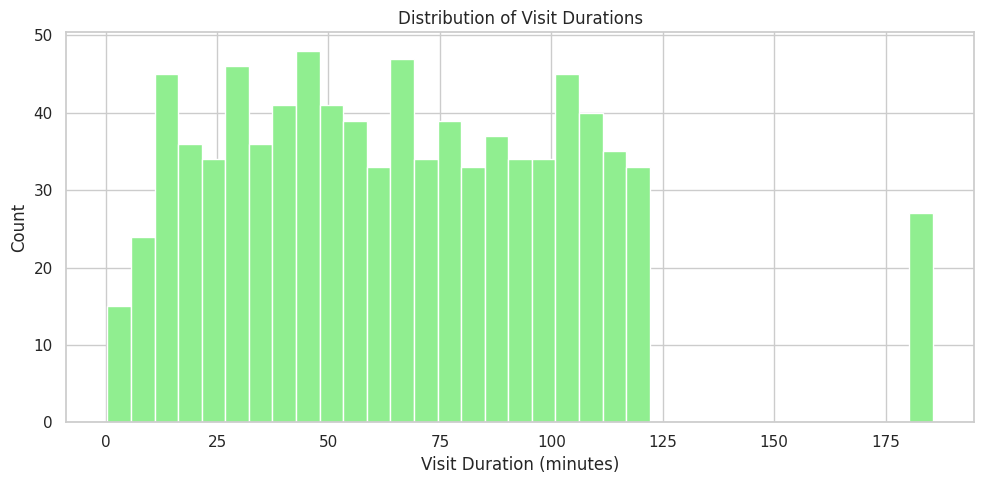

In [92]:
#histogram of visit duration
fig, ax=plt.subplots()
ax.hist(df['visit_duration_minutes'], bins=35, color='lightgreen', edgecolor='white')
ax.set_xlabel('Visit Duration (minutes)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Visit Durations')
plt.tight_layout()
plt.savefig('plots/hist_visit_duration.png', dpi=150)
plt.show()

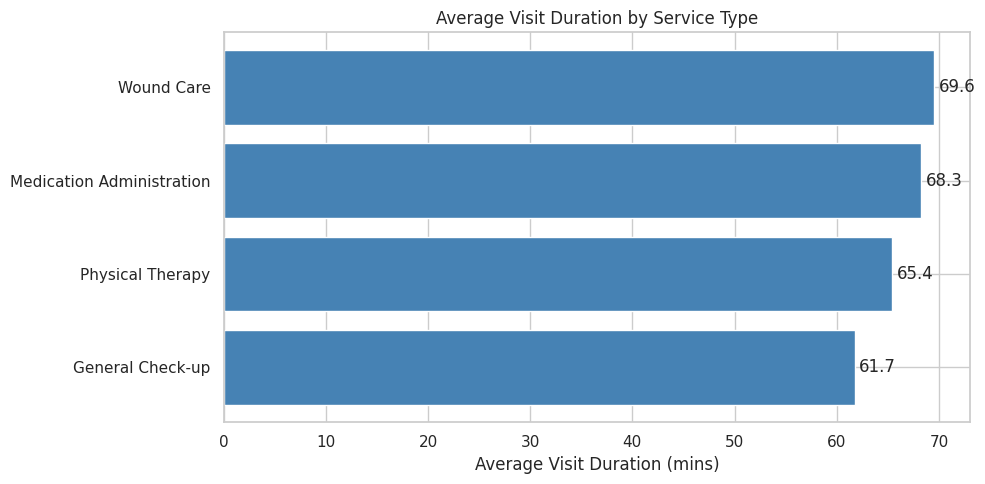

In [93]:
#bar chart of avg visit duration by service type
svc_plot=df.groupby('service_type')['visit_duration_minutes'].mean().sort_values()
fig, ax=plt.subplots()
bars=ax.barh(svc_plot.index, svc_plot.values, color='steelblue')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlabel('Average Visit Duration (mins)')
ax.set_title('Average Visit Duration by Service Type')
plt.tight_layout()
plt.savefig('plots/bar_duration_by_service.png', dpi=150)
plt.show()

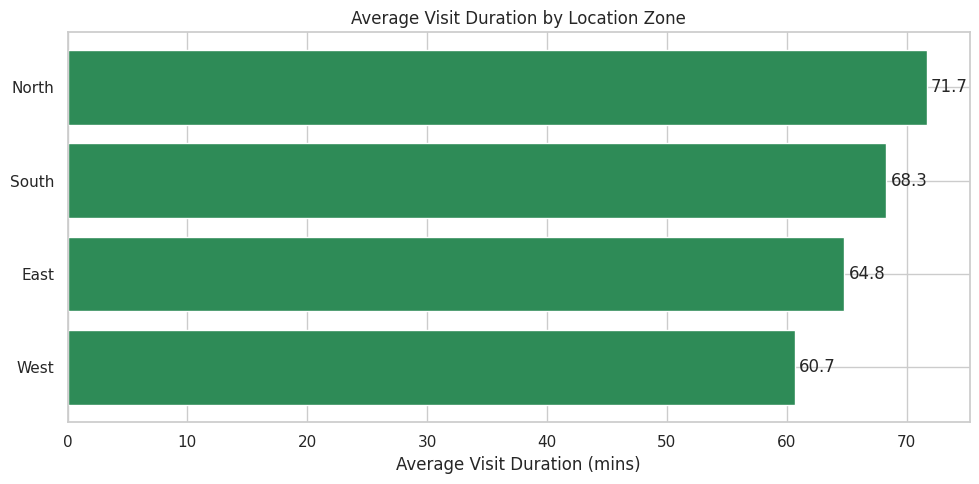

In [94]:
#bar chart of avg visit duration by location
loc_plot=df.groupby('visit_location')['visit_duration_minutes'].mean().sort_values()
fig, ax=plt.subplots()
bars=ax.barh(loc_plot.index, loc_plot.values, color='seagreen')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlabel('Average Visit Duration (mins)')
ax.set_title('Average Visit Duration by Location Zone')
plt.tight_layout()
plt.savefig('plots/bar_duration_by_location.png', dpi=150)
plt.show()

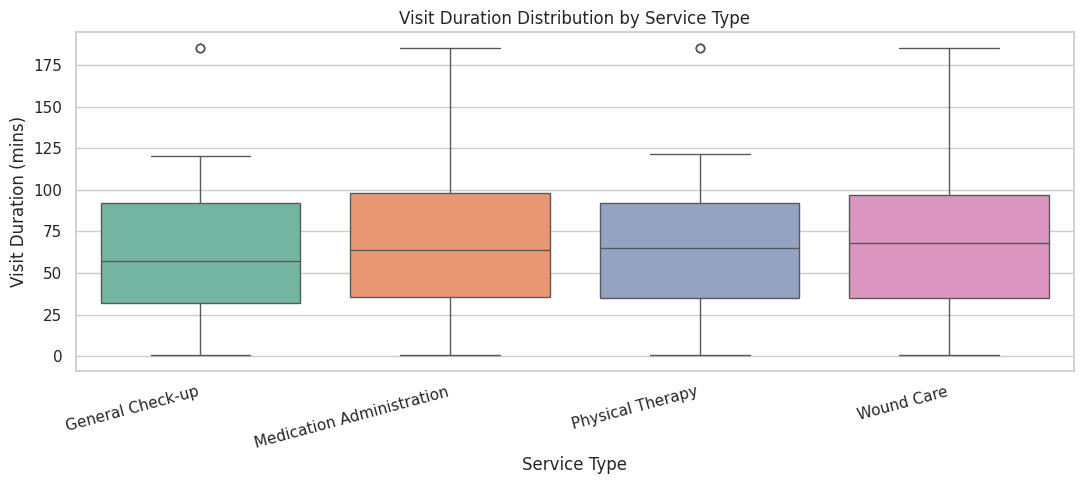

In [95]:
#boxplot of visit duration by service type
fig, ax=plt.subplots(figsize=(11, 5))
order=df.groupby('service_type')['visit_duration_minutes'].median().sort_values().index
sns.boxplot(data=df, x='service_type', y='visit_duration_minutes', order=order, palette='Set2', ax=ax)
ax.set_xlabel('Service Type')
ax.set_ylabel('Visit Duration (mins)')
ax.set_title('Visit Duration Distribution by Service Type')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/box_duration_service.png', dpi=150)
plt.show()

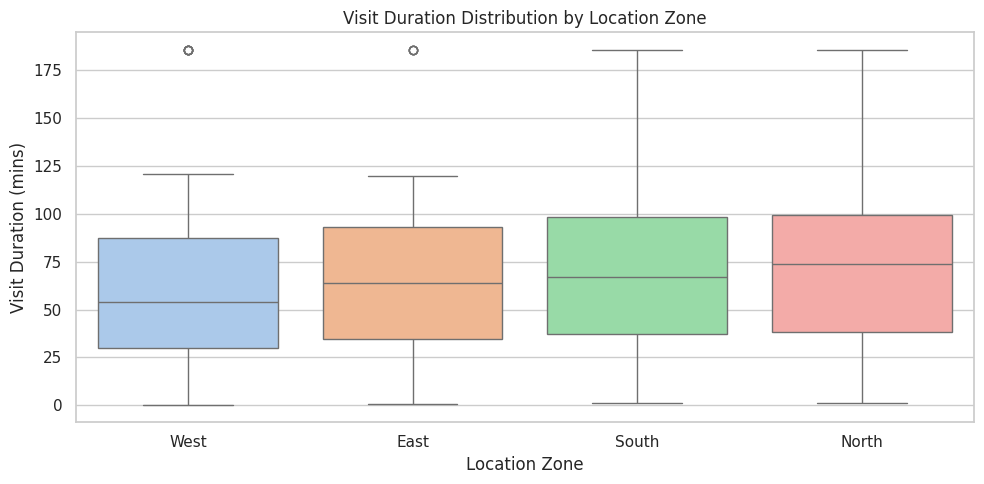

In [96]:
#boxplot of visit duration by location
fig, ax=plt.subplots()
order2=df.groupby('visit_location')['visit_duration_minutes'].median().sort_values().index
sns.boxplot(data=df, x='visit_location', y='visit_duration_minutes', order=order2, palette='pastel', ax=ax)
ax.set_xlabel('Location Zone')
ax.set_ylabel('Visit Duration (mins)')
ax.set_title('Visit Duration Distribution by Location Zone')
plt.tight_layout()
plt.savefig('plots/box_duration_location.png', dpi=150)
plt.show()

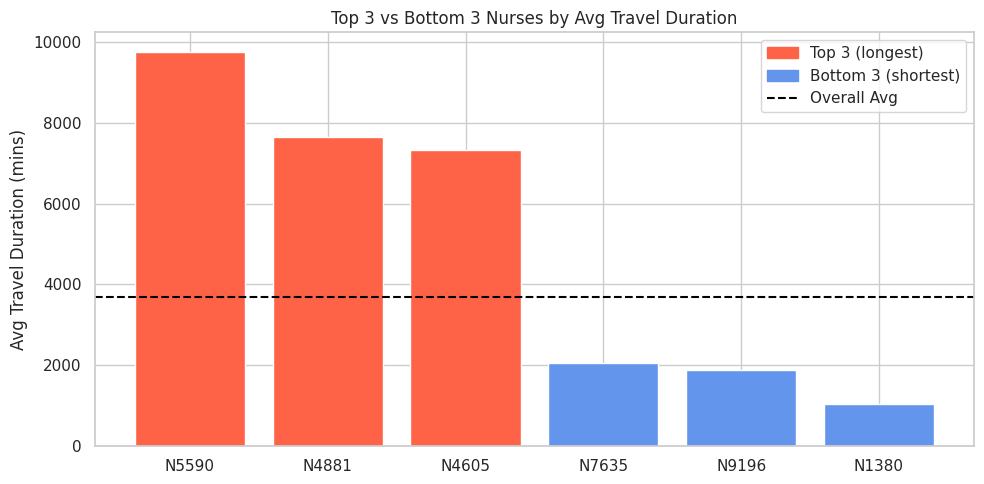

In [97]:
#top 3 vs bottom 3 nurses by avg travel duration
nurse_travel_all=df.groupby('nurse_id')['travel_duration_minutes'].mean().sort_values(ascending=False)
top3=nurse_travel_all.head(3)
bot3=nurse_travel_all.tail(3)
highlight=pd.concat([top3, bot3])
colors=['tomato']*3 + ['cornflowerblue']*3

fig, ax=plt.subplots()
ax.bar(highlight.index, highlight.values, color=colors)
ax.axhline(df['travel_duration_minutes'].mean(), color='black', linestyle='--', label=f'Overall Avg ({df["travel_duration_minutes"].mean():.1f} mins)')
ax.set_ylabel('Avg Travel Duration (mins)')
ax.set_title('Top 3 vs Bottom 3 Nurses by Avg Travel Duration')
ax.legend()

import matplotlib.patches as mpatches
red_patch=mpatches.Patch(color='tomato', label='Top 3 (longest)')
blue_patch=mpatches.Patch(color='cornflowerblue', label='Bottom 3 (shortest)')
ax.legend(handles=[red_patch, blue_patch, plt.Line2D([0],[0], color='black', linestyle='--', label='Overall Avg')])
plt.tight_layout()
plt.savefig('plots/bar_nurse_travel.png', dpi=150)
plt.show()


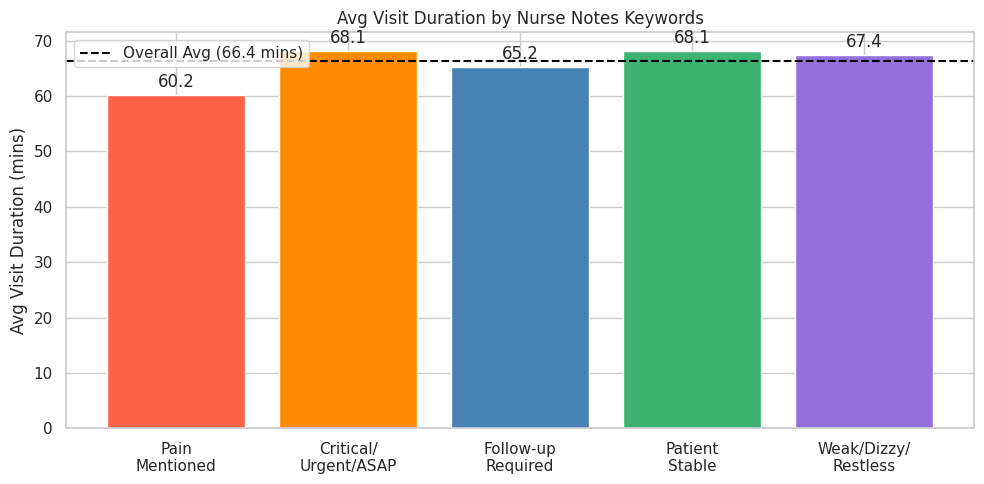

In [98]:
#avg visit duration by nurse notes flags
flag_labels={
    'flag_pain':'Pain\nMentioned',
    'flag_critical':'Critical/\nUrgent/ASAP',
    'flag_followup':'Follow-up\nRequired',
    'flag_stable':'Patient\nStable',
    'flag_weak':'Weak/Dizzy/\nRestless'
}
avgs={label: df[df[flag]==1]['visit_duration_minutes'].mean() for flag, label in flag_labels.items()}
overall=df['visit_duration_minutes'].mean()

fig, ax=plt.subplots()
bars=ax.bar(avgs.keys(), avgs.values(), color=['tomato','darkorange','steelblue','mediumseagreen','mediumpurple'])
ax.axhline(overall, color='black', linestyle='--', label=f'Overall Avg ({overall:.1f} mins)')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_ylabel('Avg Visit Duration (mins)')
ax.set_title('Avg Visit Duration by Nurse Notes Keywords')
ax.legend()
plt.tight_layout()
plt.savefig('plots/bar_notes_flags.png', dpi=150)
plt.show()
